In [7]:
#import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#libraries to standardise the columns and evaluate the models
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

#importing models to train the data
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [8]:
#Loading dataset
data = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

#See first few rows
print("TOP ROWS OF THE DATA")
print(data.head())
print("\n")

# Check info and missing values
print("DATASET INFORMATION")
print(data.info())

print("\nMISSING VALUES")
print(data.isnull().sum())

print("\nDUPLICATES")
print(f"Duplicate rows: {data.duplicated().sum()}")

print("\nBASIC STATISTICS")
print(data.describe())

TOP ROWS OF THE DATA
     Id  Therapy Hours  Initial Health Score Lifestyle Activities  \
0  9255              5                    49                   No   
1  1562              2                    48                  Yes   
2  1671              2                    81                   No   
3  6088              2                    46                   No   
4  6670              8                    47                   No   

   Average Sleep Hours  Follow-Up Sessions  Recovery Index  
0                    7                   5              36  
1                    7                   6              25  
2                    7                   2              59  
3                    6                   1              22  
4                    9                   0              40  


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------         

PREPROCESSING OF DATA

In [9]:
#since there are no null values in any column we can skip that.

#there is one object datatype column - lifestyle activities
data['Lifestyle Activities'] = data['Lifestyle Activities'].map({'Yes': 1, 'No': 0})
test['Lifestyle Activities'] = test['Lifestyle Activities'].map({'Yes': 1, 'No': 0})

ANALYSING FEATURES


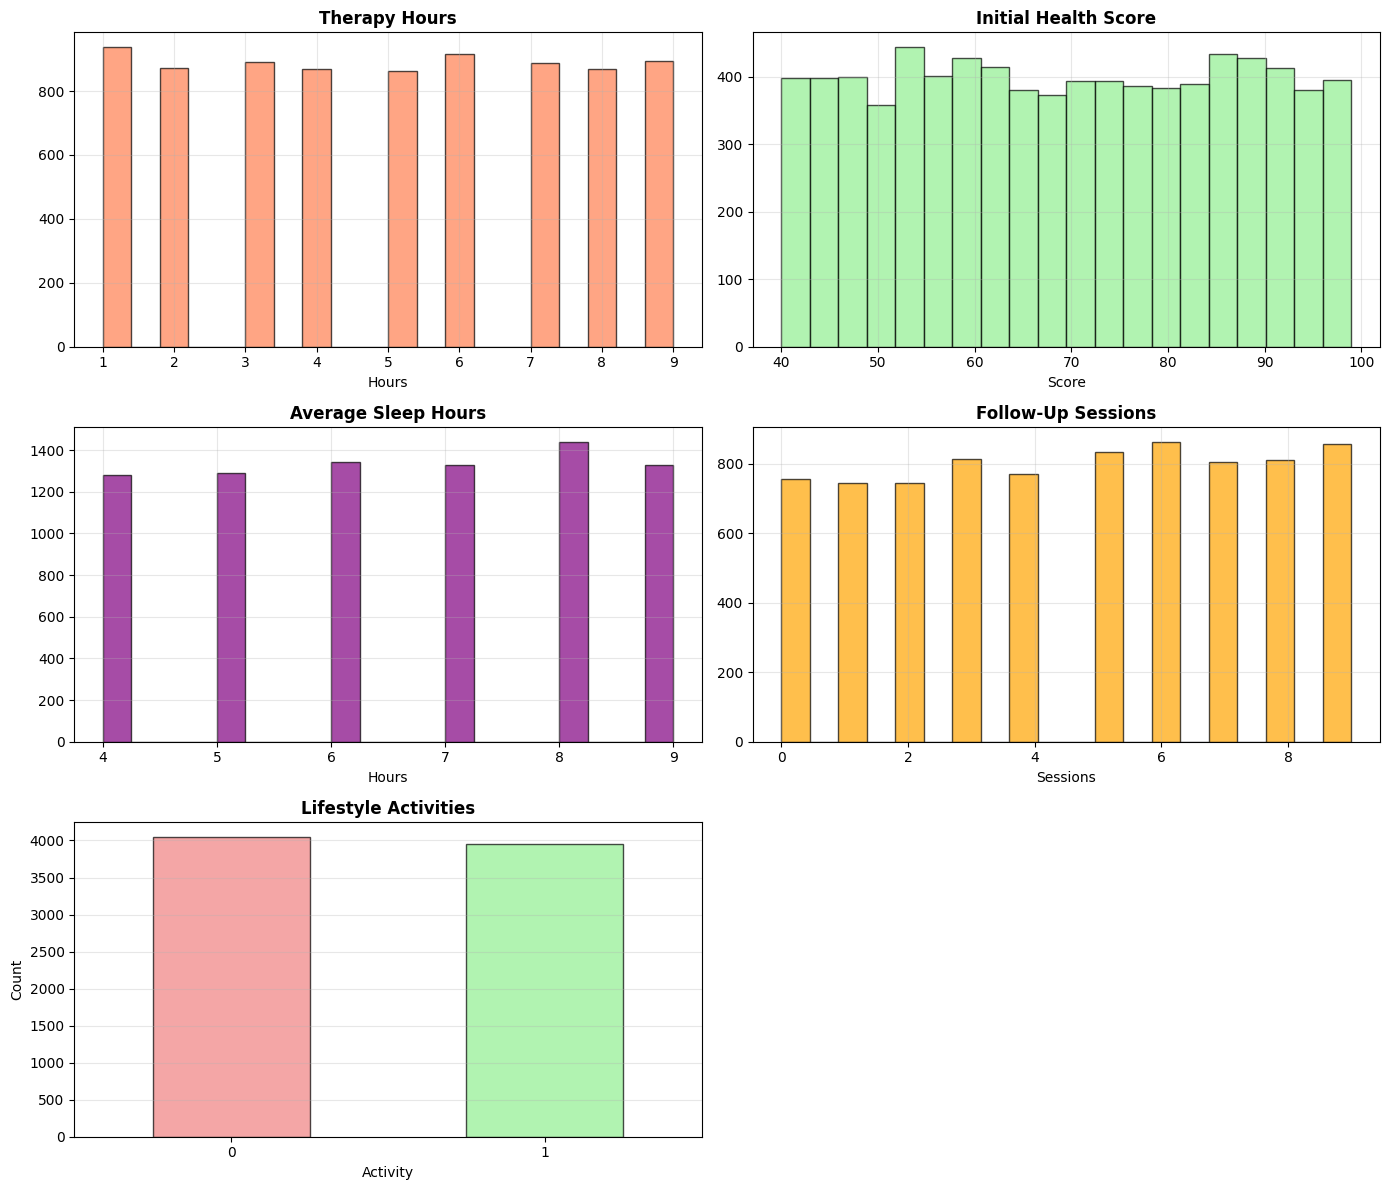

In [10]:
#Plot all features
colors = ['coral', 'lightgreen', 'purple', 'orange']
columns = ['Therapy Hours', 'Initial Health Score', 'Average Sleep Hours', 'Follow-Up Sessions']
X_labels = ['Hours', 'Score', 'Hours', 'Sessions']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

k=0
for i in range(0,2):
  for j in range (0,2):
  # Therapy Hours
    axes[i, j].hist(data[columns[k]], bins=20, edgecolor='black', color=colors[k], alpha=0.7)
    axes[i, j].set_title(columns[k], fontsize=12, fontweight='bold')
    axes[i, j].set_xlabel(X_labels[k])
    axes[i, j].grid(alpha=0.3)
    k+=1

# Lifestyle Activities
data['Lifestyle Activities'].value_counts().plot(kind='bar', ax=axes[2,0], color=['lightcoral', 'lightgreen'], edgecolor='black', alpha=0.7)
axes[2, 0].set_title('Lifestyle Activities', fontsize=12, fontweight='bold')
axes[2,0].set_xlabel('Activity')
axes[2,0].set_ylabel('Count')
axes[2,0].tick_params(axis='x', rotation=0)
axes[2,0].grid(alpha=0.3, axis='y')
axes[2,1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
correlation = data.corr()
print(correlation['Recovery Index'])

Id                      0.008825
Therapy Hours           0.376255
Initial Health Score    0.914718
Lifestyle Activities    0.018690
Average Sleep Hours     0.044435
Follow-Up Sessions      0.043888
Recovery Index          1.000000
Name: Recovery Index, dtype: float64


CORRELATION WITH RECOVERY INDEX

Initial Health Score.........................  0.915
Therapy Hours................................  0.376
Average Sleep Hours..........................  0.044
Follow-Up Sessions...........................  0.044
Lifestyle Activities.........................  0.019
Id...........................................  0.009


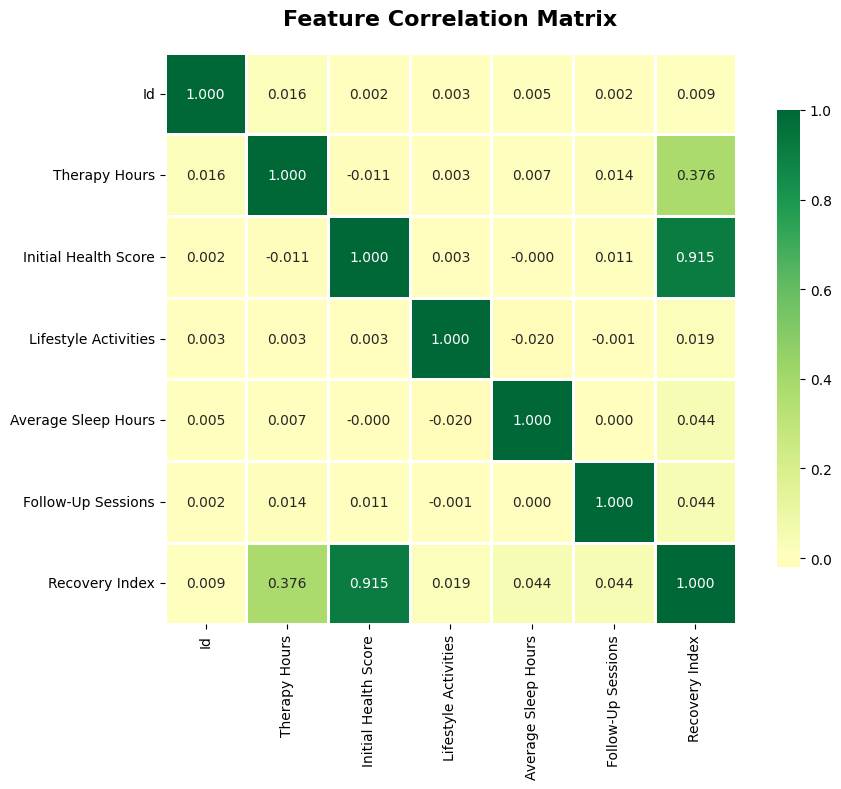

In [12]:
#Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0,
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

print("CORRELATION WITH RECOVERY INDEX\n")
corr_with_target = correlation['Recovery Index'].sort_values(ascending=False)
for feature, corr_value in corr_with_target.items():
    if feature != 'Recovery Index':
        print(f"{feature:.<45} {corr_value:>6.3f}")


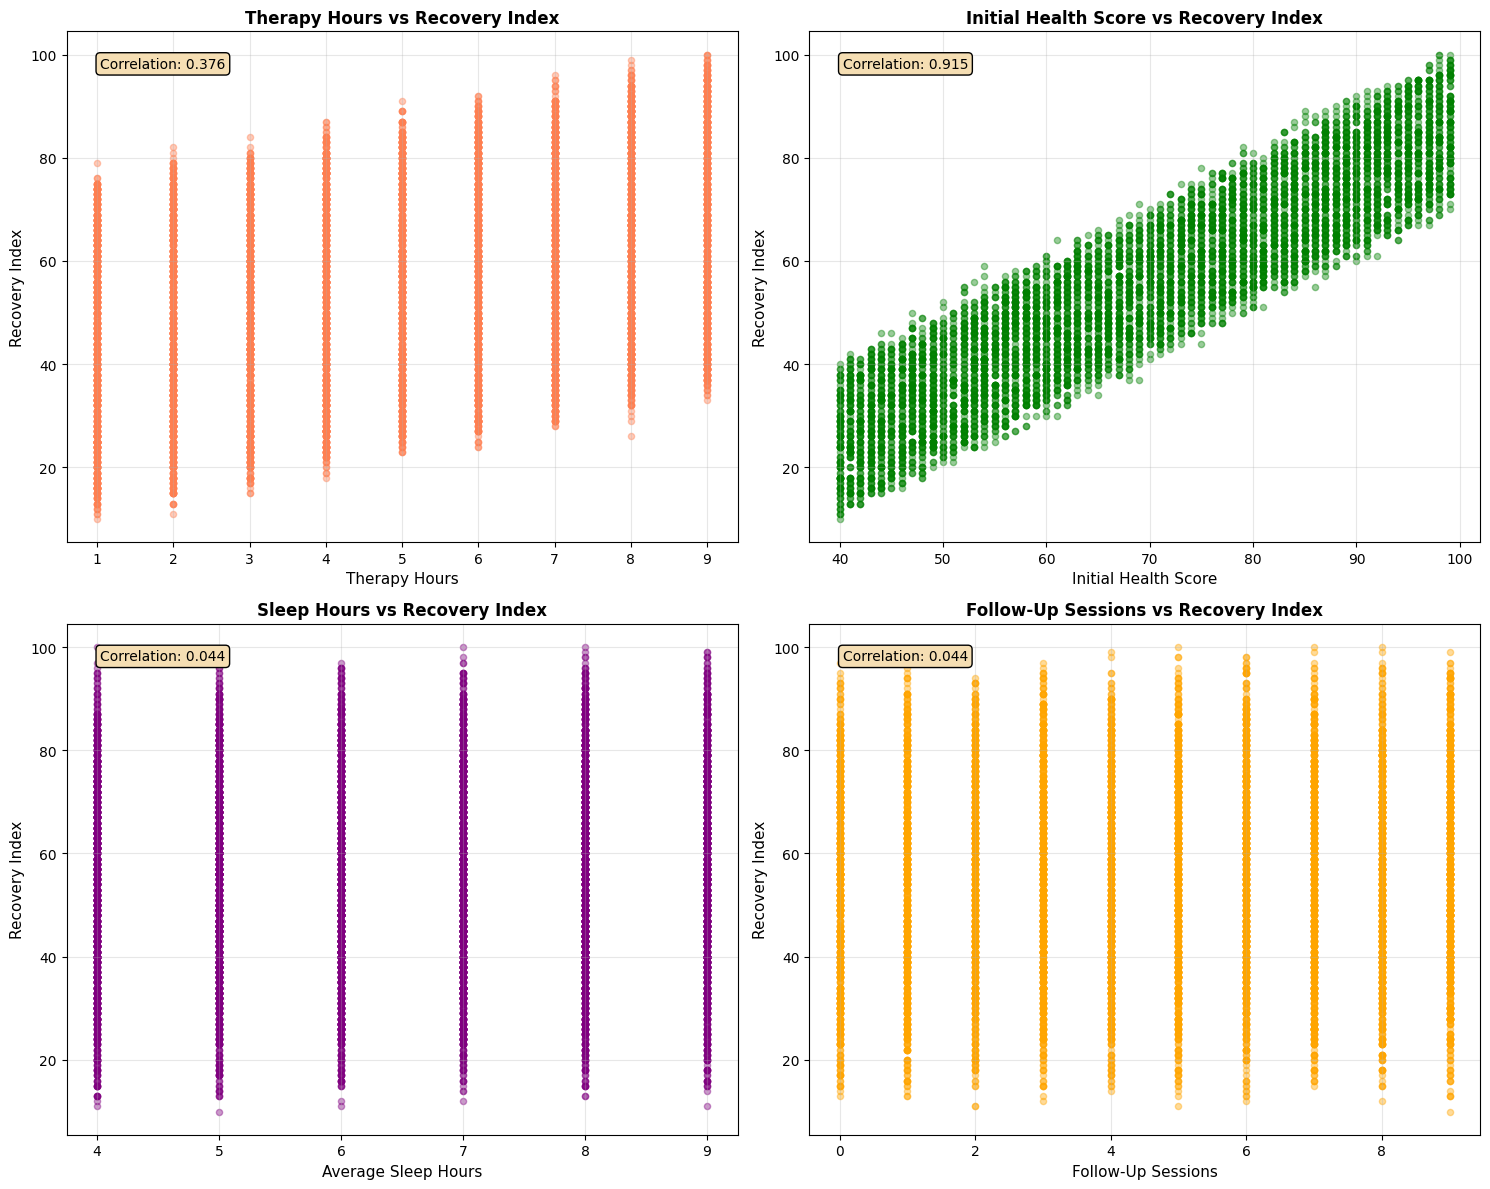

In [13]:
# Scatter plots showing relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Therapy Hours vs Recovery
axes[0, 0].scatter(data['Therapy Hours'], data['Recovery Index'], alpha=0.4, s=20, color='coral')
axes[0, 0].set_xlabel('Therapy Hours', fontsize=11)
axes[0, 0].set_ylabel('Recovery Index', fontsize=11)
axes[0, 0].set_title('Therapy Hours vs Recovery Index', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
corr = data[['Therapy Hours', 'Recovery Index']].corr().iloc[0, 1]
axes[0, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat'), fontsize=10, verticalalignment='top')

# Initial Health vs Recovery
axes[0, 1].scatter(data['Initial Health Score'], data['Recovery Index'], alpha=0.4, s=20, color='green')
axes[0, 1].set_xlabel('Initial Health Score', fontsize=11)
axes[0, 1].set_ylabel('Recovery Index', fontsize=11)
axes[0, 1].set_title('Initial Health Score vs Recovery Index', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
corr = data[['Initial Health Score', 'Recovery Index']].corr().iloc[0, 1]
axes[0, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat'), fontsize=10, verticalalignment='top')

# Sleep Hours vs Recovery
axes[1, 0].scatter(data['Average Sleep Hours'], data['Recovery Index'], alpha=0.4, s=20, color='purple')
axes[1, 0].set_xlabel('Average Sleep Hours', fontsize=11)
axes[1, 0].set_ylabel('Recovery Index', fontsize=11)
axes[1, 0].set_title('Sleep Hours vs Recovery Index', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
corr = data[['Average Sleep Hours', 'Recovery Index']].corr().iloc[0, 1]
axes[1, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat'), fontsize=10, verticalalignment='top')

# Follow-Up vs Recovery
axes[1, 1].scatter(data['Follow-Up Sessions'], data['Recovery Index'], alpha=0.4, s=20, color='orange')
axes[1, 1].set_xlabel('Follow-Up Sessions', fontsize=11)
axes[1, 1].set_ylabel('Recovery Index', fontsize=11)
axes[1, 1].set_title('Follow-Up Sessions vs Recovery Index', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
corr = data[['Follow-Up Sessions', 'Recovery Index']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat'), fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

In [14]:
#drop the target feature and the feature least correlated with it -'Id'
X = data.drop(columns=['Recovery Index', 'Id']) #features to train on
y = data['Recovery Index']          #target

test_X = test.drop(columns=['Id'])

#using random_state = 0 throughout
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

#standardising-
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val),columns=X_val.columns,index=X_val.index)
test_X = pd.DataFrame(scaler.transform(test_X),columns=test_X.columns,index=test_X.index)

print("-"*11)
print("DATA SPLIT")
print("-"*11)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")


-----------
DATA SPLIT
-----------
Training set:   6400 samples (80.0%)
Validation set: 1600 samples (20.0%)


In [15]:
print("TRAINING BASELINE MODELS")
print("-"*30)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=0),
    'Lasso': Lasso(alpha=1.0, random_state=0),
    'Decision Tree': DecisionTreeRegressor(random_state=0, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=0, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=0, max_depth=5),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5)
}

#Train and evaluate
results = []

for name, model in models.items():
    #Training model on training data
    model.fit(X_train, y_train)

    #Testing on validation data
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    #evaluation
    val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    val_r2 = r2_score(y_val, y_pred_val)

    results.append({
        'Model': name,
        'Val RMSE': val_rmse,
        'Val R²': val_r2,
    })


# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Val RMSE')

print("BASELINE MODEL RESULTS (sorted by validation RMSE)")
print("="*50)
print(results_df.to_string(index=False))

print("\n" + "="*30)
print("BEST MODEL:", results_df.iloc[0]['Model'])
print(f"Validation RMSE: {results_df.iloc[0]['Val RMSE']:.5f}")
print(f"Validation R²:   {results_df.iloc[0]['Val R²']:.5f}")

TRAINING BASELINE MODELS
------------------------------
BASELINE MODEL RESULTS (sorted by validation RMSE)
            Model  Val RMSE   Val R²
            Ridge  2.100278 0.987903
Linear Regression  2.100407 0.987902
Gradient Boosting  2.193797 0.986802
    Random Forest  2.415977 0.983993
    Decision Tree  2.645155 0.980813
            Lasso  2.720455 0.979705
        KNN (k=5)  3.087001 0.973867

BEST MODEL: Ridge
Validation RMSE: 2.10028
Validation R²:   0.98790


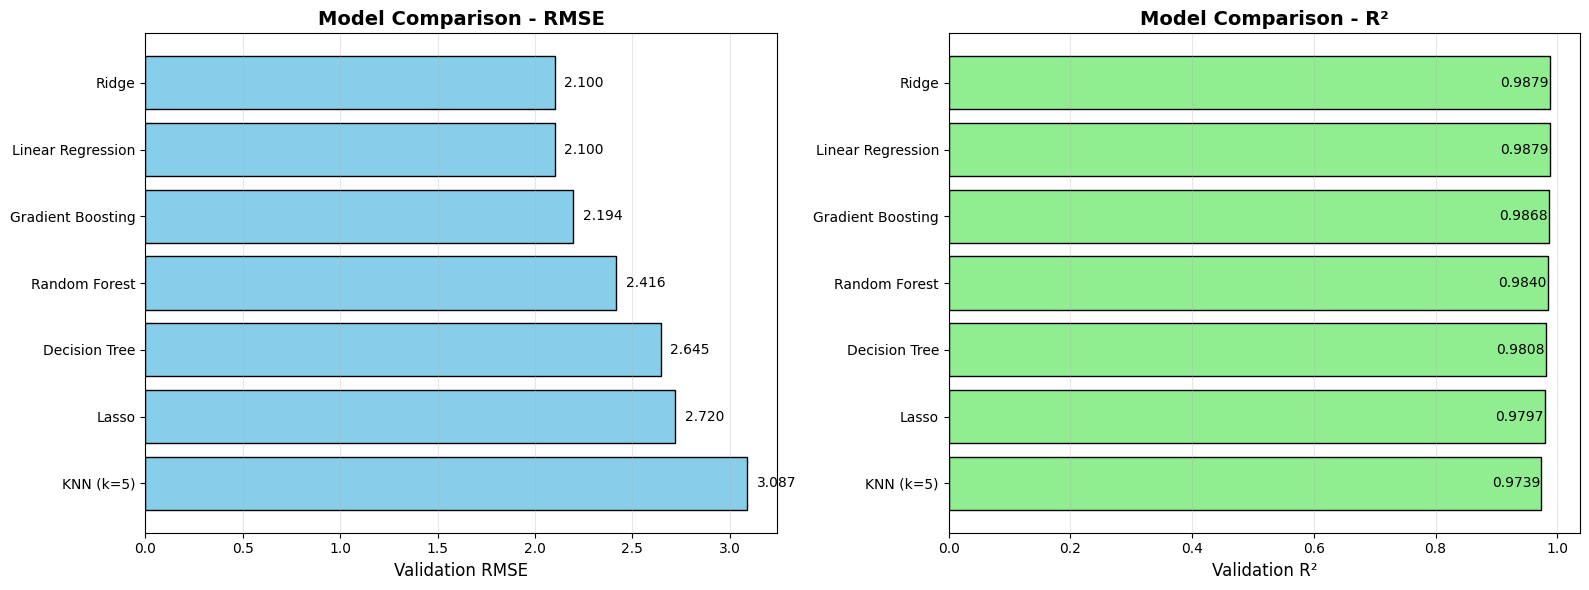

In [16]:
#Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#RMSE comparison
axes[0].barh(results_df['Model'], results_df['Val RMSE'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Validation RMSE', fontsize=12)
axes[0].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['Val RMSE']):
    axes[0].text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=10)

#R² comparison
axes[1].barh(results_df['Model'], results_df['Val R²'], color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Validation R²', fontsize=12)
axes[1].set_title('Model Comparison - R²', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['Val R²']):
    axes[1].text(v - 0.002, i, f'{v:.4f}', va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

***HYPERPARAMTER TUNING***

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)

linear_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Try different polynomial degrees
degrees = [1, 2, 3]
results = []

for d in degrees:
    linear_pipeline.set_params(poly__degree=d)
    scores = cross_val_score(
        linear_pipeline,
        X_train, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    mean_rmse = -scores.mean()
    results.append((d, mean_rmse))
    print(f"Degree {d} → Mean RMSE: {mean_rmse:.5f}")

best_degree, best_rmse = min(results, key=lambda x: x[1])
print(f"\nBest Polynomial Degree: {best_degree}")
print(f"Best RMSE: {best_rmse:.5f}\n")

Degree 1 → Mean RMSE: 2.02971
Degree 2 → Mean RMSE: 2.03331
Degree 3 → Mean RMSE: 2.04021

Best Polynomial Degree: 1
Best RMSE: 2.02971



In [18]:
#using gridsearchCV

#Ridge
# Test different alpha values for Ridge
scoring = 'neg_root_mean_squared_error'
poly = PolynomialFeatures(degree=1, include_bias=False)


ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=0))
])
param_grid_ridge = {
    'poly__degree': [1, 2, 3],            # try linear, quadratic, cubic
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]
}


ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid_ridge,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_grid.fit(X_train, y_train)

print("Best RIDGE parameters:", ridge_grid.best_params_)
print("Best RIDGE RMSE:", -ridge_grid.best_score_)


Fitting 5 folds for each of 21 candidates, totalling 105 fits
Best RIDGE parameters: {'poly__degree': 1, 'ridge__alpha': 0.001}
Best RIDGE RMSE: 2.0297082594584337


In [19]:
#Lasso

lasso_pipeline = Pipeline([
    ('poly', poly),
    ('scaler', scaler),
    ('lasso', Lasso(random_state=0, max_iter=1000))
])

param_grid_lasso = {
    'poly__degree': [1, 2, 3],
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=param_grid_lasso,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

lasso_grid.fit(X_train, y_train)

print("Best LASSO parameters:", lasso_grid.best_params_)
print("Best LASSO RMSE:", -lasso_grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best LASSO parameters: {'lasso__alpha': 0.0001, 'poly__degree': 1}
Best LASSO RMSE: 2.02970836068258


In [20]:
#Random Forest

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=0))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
print("Best RF RMSE:", -rf_grid.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF parameters: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best RF RMSE: 2.250574457547672


In [21]:
#KNeighbours
knn_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

param_grid_knn = {
    'poly__degree': [1, 2],
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid_knn,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

knn_grid.fit(X_train, y_train)

print("Best KNN parameters:", knn_grid.best_params_)
print("Best KNN RMSE:", -knn_grid.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN parameters: {'knn__n_neighbors': 9, 'knn__weights': 'distance', 'poly__degree': 1}
Best KNN RMSE: 2.9601714468001736


In [22]:
#Randomsied SearchCV for gradient boosting

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingRegressor(random_state=0))
])

param_dist_gb = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.05,0.1,0.2],
    'gb__max_depth': [2, 3, 4],
    'gb__min_samples_split': [2, 5, 10]
}

gb_random = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=0
)

gb_random.fit(X_train, y_train)

print("Best GB parameters:", gb_random.best_params_)
print("Best GB RMSE:", -gb_random.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best GB parameters: {'gb__n_estimators': 300, 'gb__min_samples_split': 5, 'gb__max_depth': 3, 'gb__learning_rate': 0.1}
Best GB RMSE: 2.104780981883748


***FEATURE ENGINEERING - WE TRY TO ADD/MODIFY FEATURES***

In [53]:
# Create copies
X_new = X.copy()

X_new = pd.DataFrame(scaler.transform(X_new),columns=X_new.columns,index=X_new.index)
X_new['therapy_health_interaction'] = X_new['Therapy Hours'] * X_new['Initial Health Score']
X_new['sleep_health_interaction'] = (X_new['Average Sleep Hours'] * X_new['Initial Health Score'])

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=0
)


test_new = test_X.copy();
test_new['therapy_health_interaction'] = test_new['Therapy Hours'] * test_new['Initial Health Score']
test_new['sleep_health_interaction'] = (test_new['Average Sleep Hours'] * test_new['Initial Health Score'])

In [58]:
lin_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('lin', LinearRegression())
])

param_grid_lin = {'poly__degree': [1, 2, 3]}

lin_grid = GridSearchCV(
    lin_pipeline,
    param_grid=param_grid_lin,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

lin_grid.fit(X_train_new, y_train_new)

print("Best Linear params:", lin_grid.best_params_)
print("Best Linear RMSE:", -lin_grid.best_score_)

best_linear = lin_grid.best_estimator_
best_linear.fit(X_train_new, y_train_new)
preds_linear = best_linear.predict(test_new)
pd.DataFrame({"Id": test["Id"], "Recovery Index": preds_linear}).to_csv("submission_linear.csv", index=False)


#Ridge Regression
ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=0))
])

param_grid_ridge = {
    'poly__degree': [1, 2, 3],
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid_ridge,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_grid.fit(X_train_new, y_train)
print("\nBest Ridge params:", ridge_grid.best_params_)
print("Best Ridge RMSE:", -ridge_grid.best_score_)

best_ridge = ridge_grid.best_estimator_
best_ridge.fit(X_train_new, y_train_new)
preds_ridge = best_ridge.predict(test_new)
pd.DataFrame({"Id": test["Id"], "Recovery Index": preds_ridge}).to_csv("submission_ridge.csv", index=False)


#Lasso Regression
lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=0, max_iter=10000))
])

param_grid_lasso = {
    'poly__degree': [1, 2, 3],
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=param_grid_lasso,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

lasso_grid.fit(X_train_new, y_train_new)
print("\nBest LASSO params:", lasso_grid.best_params_)
print("Best LASSO RMSE:", -lasso_grid.best_score_)

best_lasso = lasso_grid.best_estimator_
best_lasso.fit(X_train_new, y_train_new)
preds_lasso = best_lasso.predict(test_new)
pd.DataFrame({"Id": test["Id"], "Recovery Index": preds_lasso}).to_csv("submission_lasso.csv", index=False)


#Random Fores
rf_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=0))
])

param_dist_rf = {
    'poly__degree': [1, 2],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [3, 5, 7, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=0
)

rf_random.fit(X_train_new, y_train_new)
print("\nBest RF params:", rf_random.best_params_)
print("Best RF RMSE:", -rf_random.best_score_)

best_rf = rf_random.best_estimator_
best_rf.fit(X_train_new, y_train_new)
preds_rf = best_rf.predict(test_new)
pd.DataFrame({"Id": test["Id"], "Recovery Index": preds_rf}).to_csv("submission_rf.csv", index=False)

#Gradient Boosting (RandomizedSearch)

gb_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingRegressor(random_state=0))
])

param_dist_gb = {
    'poly__degree': [1, 2],
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': np.linspace(0.05, 0.2, 5),
    'gb__max_depth': [2, 3, 4],
    'gb__min_samples_split': [2, 5]
}

gb_random = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=0
)

gb_random.fit(X_train_new, y_train_new)
print("\nBest GB params:", gb_random.best_params_)
print("Best GB RMSE:", -gb_random.best_score_)

best_gb = gb_random.best_estimator_
best_gb.fit(X_train_new, y_train_new)
preds_gb = best_gb.predict(test_new)
pd.DataFrame({"Id": test["Id"], "Recovery Index": preds_gb}).to_csv("submission_gb.csv", index=False)

Best Linear params: {'poly__degree': 1}
Best Linear RMSE: 2.03200052644115

Best Ridge params: {'poly__degree': 1, 'ridge__alpha': 0.01}
Best Ridge RMSE: 2.0320005262316667

Best LASSO params: {'lasso__alpha': 0.01, 'poly__degree': 1}
Best LASSO RMSE: 2.0312742855315955


KeyboardInterrupt: 

In [62]:
print("\n" + "="*80)
print("Method 2: Weighted Average")
print("-" * 60)

# Try different weight combinations
weight_combos = [
    (0.7, 0.2, 0.1),  # Ridge heavy
    (0.6, 0.3, 0.1),
    (0.5, 0.3, 0.2),
    (0.4, 0.4, 0.2),
    (0.33, 0.33, 0.34)  # Equal weights
]

best_weights = None
best_ensemble_rmse = float('inf')

print("Testing different weight combinations...")
print("(Ridge, Random Forest, Gradient Boosting)")
print()

for weights in weight_combos:
    w1, w2, w3 = weights
    pred_weighted = w1 * preds_ridge + w2 * preds_rf + w3 * preds_gb
    rmse = np.sqrt(mean_squared_error(y_val, pred_weighted))

    print(f"Weights ({w1:.1f}, {w2:.1f}, {w3:.1f})  →  MAE = {rmse:.4f}")

    if rmse < best_ensemble_rmse:
        best_ensemble_rmse = rmse
        best_weights = weights

print(f"\nBest weights: {best_weights}")
print(f"Best Ensemble RMSE: {best_ensemble_rmse:.4f}")


Method 2: Weighted Average
------------------------------------------------------------
Testing different weight combinations...
(Ridge, Random Forest, Gradient Boosting)



ValueError: Found input variables with inconsistent numbers of samples: [8000, 2000]